# Pytorch动态计算图与梯度下降入门

&emsp;&emsp;Pytorch中的AutoGrad（自动微分）模块是Pytorch的核心模块之一，我们将讲解AutoGrad模块中的常用功能，并在此基础上介绍另一个深度学习中最基础、最重要的一个优化算法：梯度下降算法。

In [1]:
import numpy as np
import torch

## 一、AutoGrad的回溯机制与动态计算图

### 1.可微分性相关属性

&emsp;&emsp;新版PyTorch中的张量已经不仅仅是一个纯计算的载体，张量本身也可支持微分运算。这种可微分性其实不仅体现在我们可以使用grad函数对其进行求导，更重要的是这种可微分性会体现在可微分张量参与的所有运算中。

- requires_grad属性：可微分性

In [2]:
# requires_grad=True告诉PyTorch需要跟踪这个张量的操作，并允许计算其梯度。
x = torch.tensor(1.,requires_grad = True)
x

tensor(1., requires_grad=True)

- grad_fn属性：存储Tensor微分函数

In [3]:
# 构建函数关系（改变 x 的值时，y 的值会根据这个关系自动更新）
y = x ** 2

In [4]:
# <PowBackward0> 是幂运算的反向传播函数的名称
# grad_fn=<PowBackward0> 表示这个张量是通过一个幂运算（乘方运算）得到的
y

tensor(1., grad_fn=<PowBackward0>)

我们发现，此时张量y具有了一个`grad_fn`属性，并且取值为`<PowBackward0>`，我们可以查看该属性

In [5]:
# at 0x2065d05cfa0 表示这个对象在内存中的地址
# 这是一个唯一的标识符，用于跟踪对象在计算图中的位置
y.grad_fn

`grad_fn`其实是存储了Tensor的微分函数，或者说`grad_fn`存储了可微分张量在进行计算的过程中函数关系，此处x到y其实就是进行了幂运算。

In [6]:
# 但x作为初始张量，并没有grad_fn属性
x.grad_fn

这里值得主要的是，y不仅和x存在幂运算关系（y = x\**2），更重要的是，y本身还是一个由x张量计算得出的一个张量，而对于一个可微分张量（只需要有一个）生成的张量，其也是可微分的

In [8]:
y

tensor(1., grad_fn=<PowBackward0>)

In [7]:
y.requires_grad

True

也就是相比于x，张量y不仅有取值，并且同样可微，还额外存储了x到y的函数计算信息。我们再尝试围绕y创建新的函数关系，z = y + 1

In [9]:
z = y + 1

In [10]:
# grad_fn=<AddBackward0> 表示这个张量是通过加法操作计算而来的
z

tensor(2., grad_fn=<AddBackward0>)

In [11]:
z.requires_grad

True

In [12]:
z.grad_fn

不难发现，z也同时存储了张量计算数值、z是可微的，并且z还存储了和y的计算关系（add）。据此我们可以知道，在PyTorch的张量计算过程中，如果我们设置初始张量是可微的，则在计算过程中，每一个由原张量计算得出的新张量都是可微的，并且还会保存此前一步的函数关系，这也就是所谓的回溯机制。而根据这个回溯机制，我们就能非常清楚掌握张量的每一步计算，并据此绘制张量计算图。

### 2.张量计算图

&emsp;&emsp;借助回溯机制，我们就能将张量的复杂计算过程抽象为一张计算图，例如此前我们定义的x、y、z三个张量，三者的计算关系就可以由下图进行表示。

<img src="https://i.loli.net/2021/01/23/cgrnBZqPS3vWM6U.jpg" alt="10" style="zoom:50%;" />

- 计算图的定义

&emsp;&emsp;上图就是用于记录可微分张量计算关系的张量计算图，图由节点和有向边构成，其中节点表示张量，边表示函数计算关系，方向则表示实际运算方向，张量计算图本质是有向无环图。

- 节点类型      

&emsp;&emsp;在张量计算图中，虽然每个节点都表示可微分张量，但节点和节点之间却略有不同。就像在前例中，y和z保存了函数计算关系，但x没有，而在实际计算关系中，我们不难发现z是所有计算的终点，因此，虽然x、y、z都是节点，但每个节点却并不一样。此处我们可以将节点分为三类，分别是：     
a)：叶节点，也就是初始输入的可微分张量，前例中x就是叶节点；      
b)：输出节点，也就是最后计算得出的张量，前例中z就是输出节点；      
c)：中间节点，在一张计算图中，除了叶节点和输出节点，其他都是中间节点，前例中y就是中间节点。      
当然，在一张计算图中，可以有多个叶节点和中间节点，但大多数情况下，只有一个输出节点，若存在多个输出结果，我们也往往会将其保存在一个张量中。

### 3.计算图的动态性

&emsp;&emsp;值得一提的是，PyTorch的计算图是动态计算图，会根据可微分张量的计算过程自动生成，并且伴随着新张量或运算的加入不断更新，这使得PyTorch的计算图更加灵活高效，并且更加易于构建，相比于先构件图后执行计算的部分框架（如老版本的TensorFlow），动态图也更加适用于面向对象编程。

## 二、反向传播与梯度计算

### 1.反向传播的基本过程

首先，对于某一个可微分张量的导数值（梯度值），存储在grad属性中。

In [13]:
x.grad

在最初，x.grad属性是空值，不会返回任何结果，我们虽然已经构建了x、y、z三者之间的函数关系，x也有具体取值，但要计算x点导数，还需要进行执行反向传播。所谓反向传播，我们可以简单理解为，在此前记录的函数关系基础上，反向传播函数关系，进而求得叶节点的导数值。

In [14]:
z

tensor(2., grad_fn=<AddBackward0>)

In [15]:
z.grad_fn

反向传播结束后，即可查看叶节点的导数值

In [16]:
# 执行反向传播
z.backward()

In [18]:
# 在z=y+1=x**2+1函数关系基础上，x取值为1时的导数值
x.grad

tensor(2.)

注意，在默认情况下，在一张计算图上执行反向传播，只能计算一次，再次调用backward方法将报错

In [19]:
z.backward()

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

当然，在y上也能执行反向传播

In [20]:
x = torch.tensor(1.,requires_grad = True)
y = x ** 2
z = y + 1

In [21]:
y.backward()

In [22]:
x.grad

tensor(2.)

第二次执行时也会报错

In [23]:
y.backward()

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [24]:
z.backward()

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

无论何时，我们只能访问叶节点的导数值

In [25]:
# 只能访问x的grad， y的不能访问（在大部分情形下，也无需访问） 
y.grad

C:\Users\Lzy\AppData\Local\Temp\ipykernel_15344\634158324.py:2: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten\src\ATen/core/TensorBody.h:491.)
  y.grad


4eb507c2d2911d4aebe1cd1e78127ca45fcf402e68db83d55a82698f3cc37923.png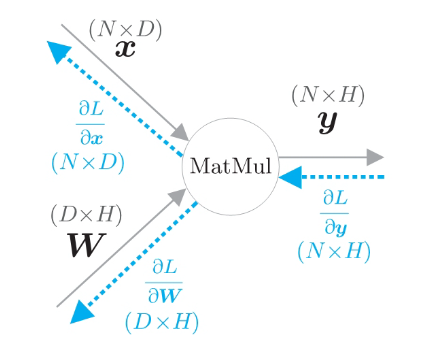

至此，我们就了解了反向传播的基本概念和使用方法：      
- 反向传播的本质：函数关系的反向传播（不是反函数）； 
- 反向传播的执行条件：拥有函数关系的可微分张量（计算图中除了叶节点的其他节点）；
- 反向传播的函数作用：计算**叶节点**的导数/微分/梯度运算结果；

### 2.反向传播运算注意事项

- 中间节点反向传播和输出节点反向传播区别

&emsp;&emsp;尽管中间节点也可进行反向传播，但很多时候由于存在复合函数关系，中间节点反向传播的计算结果和输出节点反向传播输出结果并不相同。

In [ ]:
x = torch.tensor(1.,requires_grad = True)
y = x ** 2
z = y ** 2

In [ ]:
z.backward()

<img src="2.jpg" width="391" height="151">

In [ ]:
x.grad

tensor(4.)

In [ ]:
x = torch.tensor(1.,requires_grad = True)
y = x ** 2
z = y ** 2

In [ ]:
y.backward()
x.grad

tensor(2.)

- 中间节点的梯度保存

&emsp;&emsp;默认情况下，在反向传播过程中，中间节点并不会保存梯度

In [26]:
x = torch.tensor(1.,requires_grad = True)
y = x ** 2
z = y ** 2

In [27]:
z.backward()
y.grad

C:\Users\Lzy\AppData\Local\Temp\ipykernel_15344\263072824.py:2: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten\src\ATen/core/TensorBody.h:491.)
  y.grad


In [28]:
x.grad

tensor(4.)

若想保存中间节点的梯度，我们可以使用retain_grad()方法

In [29]:
x = torch.tensor(1.,requires_grad = True)
y = x ** 2
y.retain_grad()
z = y ** 2
z.backward()

In [32]:
y.grad

tensor(2.)

In [33]:
x.grad

tensor(4.)

### 3.阻止计算图追踪

&emsp;&emsp;在默认情况下，只要初始张量是可微分张量，系统就会自动追踪其相关运算，并保存在计算图关系中，我们也可通过grad_fn来查看记录的函数关系，但在特殊的情况下，我们并不希望可微张量从创建到运算结果输出都被记录，此时就可以使用一些方法来阻止部分运算被记录。

- with torch.no_grad()：阻止计算图记录

&emsp;&emsp;例如，我们希望x、y的函数关系被记录，而y的后续其他运算不被记录，可以使用with torch.no_grad()来组织部分y的运算不被记录。

In [34]:
x = torch.tensor(1.,requires_grad = True)
y = x ** 2

In [35]:
with torch.no_grad():
    z = y ** 2

with相当于是一个上下文管理器，with torch.no_grad()内部代码都“屏蔽”了计算图的追踪记录

In [36]:
z

tensor(1.)

In [37]:
z.requires_grad

False

In [38]:
y

tensor(1., grad_fn=<PowBackward0>)

- .detach()方法：创建一个不可导的相同张量

在某些情况下，我们也可以创建一个不可导的相同张量参与后续运算，从而阻断计算图的追踪

In [39]:
x = torch.tensor(1.,requires_grad = True)
y = x ** 2
y1 = y.detach()
z = y1 ** 2

In [40]:
y

tensor(1., grad_fn=<PowBackward0>)

In [41]:
y1

tensor(1.)

In [42]:
z

tensor(1.)

### 4.识别叶节点

&emsp;&emsp;由于叶节点较为特殊，如果需要识别在一个计算图中某张量是否是叶节点，可以使用is_leaf属性查看对应张量是否是叶节点。

In [43]:
x.is_leaf

True

In [44]:
y.is_leaf

False

但is_leaf方法也有容易混淆的地方，对于任何一个新创建的张量，无论是否可导、是否加入计算图，都可以是叶节点，这些节点距离真正的叶节点，只差一个requires_grad属性调整。

In [45]:
torch.tensor([1]).is_leaf

True

In [46]:
# 经过detach的张量，也可以是叶节点
y1

tensor(1.)

In [47]:
y1.is_leaf

True

### 三、梯度下降基本思想

&emsp;&emsp;有了AutoGrad模块中各函数方法的支持，接下来，我们就能尝试手动构建另一个优化算法：梯度下降算法。

### 1.梯度下降核心思想

&emsp;&emsp;梯度下降的核心就是希望能够通过数学意义上的迭代运算，从一个随机点出发，一步步逼近最优解。

在求解简单线性回归方程的过程中，我们曾查看SSE的三维函数图像如下：

In [ ]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# 创建了一个从-1到3的NumPy数组 x，步长为0.05
x = np.arange(-1,3,0.05)
y = np.arange(-1,3,0.05)
# 使用 np.meshgrid 函数将 x 和 y 数组转换为二维网格
a, b = np.meshgrid(x, y)
# 计算了一个平方误差和（SSE）的函数
SSE = (2 - a - b) ** 2 + (4 - 3 * a - b) ** 2

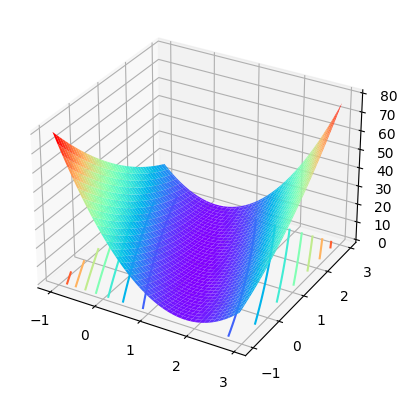

In [ ]:
# 创建一个新的 Matplotlib 图形对象 fig，这将是可视化的主窗口
fig = plt.figure() 
# 创建一个三维坐标轴对象 ax，并指定它的投影类型为 '3d'，表示我们要创建一个三维图形
ax = plt.axes(projection='3d')
# 使用三维坐标轴 ax 上的 plot_surface 方法，绘制三维曲面图
ax.plot_surface(a, b, SSE, cmap='rainbow')
# 使用三维坐标轴 ax 上的 contour 方法，生成误差曲面在 z 方向的投影，投影到 x-y 平面上
ax.contour(a, b, SSE, zdir='z', offset=0, cmap="rainbow")
plt.show()

而梯度下降，作为最优化算法，核心目标也是找到或者逼近最小值点，而其基本过程则：
- 在目标函数上随机找到一个初始点；
- 通过迭代运算，一步步逼近最小值点；

<img src="https://i.loli.net/2021/01/23/caNAtMFI5dqhfH6.jpg" alt="11" style="zoom:50%;" />

## 四、梯度下降求解多元线性回归的数学表示

### 1.代数表示

&emsp;&emsp;根据上述描述过程，我们可以总结利用梯度下降运算解决多元线性回归问题的一般过程

令多元线性回归方程为

<center> $ f(x) = w_1x_1+w_2x_2+...+w_dx_d+b $ </center>

令

$$\hat w = (w_1,w_2,...,w_d,b)$$

$$\hat x = (x_1,x_2,...,x_d,1)$$

出于加快迭代收敛速度的目标，我们在定义梯度下降的损失函数L时，在原SSE基础上进行比例修正，新的损失函数$L(w_1,w_2,...,w_d,b) = \frac{1}{2m}SSE$，其中，m为样本个数。

损失函数有：

 $$
   L(w_1,w_2,...,w_d,b) = \frac{1}{2m}\sum_{j=0}^{m}(f(x_1^{(j)}, x_2^{(j)}, ...1) - y_j)^2
   $$

并且，根据此前描述过程，在开始梯度下降求解参数之前，我们首先需要设置一组参数的初始取值$(w_1, w_2..., w_d, b)$，以及学习率$\alpha$，然后即可执行迭代运算，其中每一轮迭代过程需要执行以下三步

Step 1.计算梯度表达式

对于任意一个参数$w_i$，其梯度计算表达式如下：

$$\frac{\partial}{\partial w_i}L(w_1, w_2..., w_d, b)$$

Step 2.用学习率乘以损失函数梯度，得到迭代移动距离

$$\alpha \frac{\partial}{\partial w_i}L(w_1, w_2..., w_d, b)$$

Step 3.用原参数减Step 2中计算得到的距离，更新所有的参数w

$$w_i = w_i - \alpha \frac{\partial}{\partial w_i}L(w_1, w_2..., w_d, b)$$

更新完所有参数，即完成了一轮的迭代，接下来就能以新的一组$w_i$参与下一轮迭代。

而何时停止迭代，一般来说有两种情况，其一是设置迭代次数，到达迭代次数即停止迭代；其二则是设置收敛区间，即当某两次迭代过程中，每个$w_i$更新的数值都小于某个预设的值，则停止迭代。

步长的设置方法
- 步长太短：会极大的影响迭代收敛的时间，整体计算效率会非常低；

<img src="https://i.loli.net/2021/01/23/jDFKx6sMePUYpIn.jpg" alt="14" style="zoom:50%;" />

- 步长太长：容易跳过最优解，导致结果震荡。      

<img src="https://i.loli.net/2021/01/23/2a1ZEAz7BILrReO.jpg" alt="13" style="zoom:50%;" />

关于步长的设置，其实更多的会和实际使用情况相关，和实际损失函数特性相关，因此我们会在后续使用梯度下降求解目标函数时根据实际情况，讲解步长的实际调整策略。

### 2.梯度下降的矩阵表示

$$ X = 
\left [\begin{array}{cccc}
x_{11} &x_{12} &... &x_{1d} &1 \\
x_{21} &x_{22} &... &x_{2d} &1 \\
... &... &... &... &1 \\
x_{m1} &x_{12} &... &x_{md} &1 \\
\end{array}\right]
$$

对应到前例中的A矩阵，A矩阵就是拥有一个自变量、两个取值的X矩阵。令y为自变量的取值，则有

$$ y =  \left [\begin{array}{cccc}
y_1 \\
y_2 \\
. \\
. \\
. \\
y_m \\
\end{array}\right] $$

此时，SSE可表示为：

$$SSE = ||y - X\hat w^T||_2^2 = (y - X\hat w^T)^T(y - X\hat w^T) = E(\hat w)$$

梯度下降损失函数为：

$$L(\hat w) = \frac{1}{2m} SSE =\frac{1}{2m} (y - X\hat w^T)^T(y - X\hat w^T) $$

同样，我们需要设置初始化参数$(w_1, w_2..., w_d, b)$，以及学习率$\alpha$，然后即可开始执行迭代过程，同样，每一轮迭代需要有三步计算：

Step 1.计算梯度表达式

对于参数向量$\hat w$，其梯度计算表达式如下：

$$\frac{\partial}{\partial \hat w}L(\hat w) = \frac{1}{m}X^T(X\hat w ^T - Y)$$

Step 2.用学习率乘以损失函数梯度，得到迭代移动距离

$$\alpha \frac{\partial}{\partial \hat w}L(\hat w)$$

Step 3.用原参数减Step 2中计算得到的距离，更新所有的参数w

$$\hat w = \hat w - \alpha \frac{\partial}{\partial \hat w}L(\hat w) = \hat w - \frac{\alpha}{m}X^T(X\hat w ^T - Y)$$

更新完所有参数，即完成了一轮的迭代，接下来就能以新的$\hat w$参与下一轮迭代。

# 五、手动实现梯度下降

&emsp;&emsp;接下来，我们使用上述矩阵表示的梯度下降公式，围绕此前的简单线性回归的目标函数，利用此前介绍的AutoGrad模块中的梯度计算功能，来进行手动求解梯度下降。

<center> $ 1*a + b = 2 $ <\center> 
<center> $ 3*a + b = 4 $ <\center> 

在转化为矩阵表示的过程中，我们令

$$ X = 
\left [\begin{array}{cccc}
1 &1 \\
3 &1 \\
\end{array}\right]
$$

$$ y =  \left [\begin{array}{cccc}
2 \\
4 \\
\end{array}\right] $$

$$ \hat w =  \left [\begin{array}{cccc}
a \\
b \\
\end{array}\right] $$

- 手动尝试实现一轮迭代

In [48]:
# 设置初始参数
# 创建了一个包含两个元素的列向量（2 行 1 列），并将其初始化为零
weights = torch.zeros(2, 1, requires_grad = True)
weights

tensor([[0.],
        [0.]], requires_grad=True)

In [49]:
# 特征张量
# 创建 PyTorch 张量（tensor）,X 张量是一个 2x2 的二维张量
X = torch.tensor([[1.,1],[3, 1]], requires_grad = True)
X

tensor([[1., 1.],
        [3., 1.]], requires_grad=True)

In [50]:
# 创建了一个包含两个元素的 PyTorch 张量 y 并将其变成一个 2x1 的张量
y = torch.tensor([2.,4], requires_grad = True).reshape(2,1)
y

tensor([[2.],
        [4.]], grad_fn=<ReshapeAliasBackward0>)

In [51]:
# 设置步长
# 创建了一个带有初始值 0.01 的 PyTorch 张量 eps，并将其标记为需要计算梯度
eps = torch.tensor(0.01, requires_grad = True)
eps

tensor(0.0100, requires_grad=True)

In [52]:
# 梯度计算公式
'''
X.t()：这一部分是对矩阵 X 进行转置操作
torch.mm(X, weights)：矩阵乘法操作，乘法的结果是一个列向量，表示模型的预测值
torch.mm(X.t(), (torch.mm(X, weights) - y)):
左侧的矩阵是 X 的转置，右侧的矩阵是模型的预测误差
/2即/m
'''
grad = torch.mm(X.t(), (torch.mm(X, weights) - y))/2

In [53]:
grad

tensor([[-7.],
        [-3.]], grad_fn=<DivBackward0>)

注意对比代数方程计算结果，初始梯度为（-28，-12），此处相差4，也就是2m，m是样本个数。

In [54]:
weights = weights - eps * grad

In [55]:
weights

tensor([[0.0700],
        [0.0300]], grad_fn=<SubBackward0>)

- 迭代3轮

In [56]:
for k in range(3):
    grad = torch.mm(X.t(), (torch.mm(X, weights) - y))/2
    weights = weights - eps * grad

In [57]:
weights

tensor([[0.2563],
        [0.1102]], grad_fn=<SubBackward0>)

- 编写函数进行迭代运算

In [58]:
# 手动计算weights的梯度
'''
X：输入特征矩阵，包含样本和特征
y：真实标签，与输入特征对应
eps：学习率，用于控制每次权重更新的步长。默认值为 0.01
numIt：迭代次数，表示梯度下降算法要执行的更新权重的次数。默认值为 1000
'''
def gradDescent(X, y, eps = torch.tensor(0.01, requires_grad = True), numIt = 1000):
    # 输入特征矩阵 X 的形状，其中 m 表示样本数(行)，n 表示特征数（列）
    m, n = X.shape
    # 初始化模型的权重 weights，它是一个列向量，初始值全部设为 0
    weights = torch.zeros(n, 1)
    for k in range(numIt):
        grad = torch.mm(X.t(), (torch.mm(X, weights) - y))/2
        weights = weights - eps * grad
    return weights

In [59]:
# 利用自动微分机制求得weights的梯度
'''
X：输入特征矩阵，包含样本和特征
y：真实标签，与输入特征对应
eps：学习率，用于控制每次权重更新的步长。默认值为 0.01
numIt：迭代次数，表示梯度下降算法要执行的更新权重的次数。默认值为 1000
'''
def gradDescentAutoGrad(X, y, eps = torch.tensor(0.01), numIt = 1000):
    # 输入特征矩阵 X 的形状，其中 m 表示样本数(行)，n 表示特征数（列）
    m, n = X.shape
    # 初始化权重 weights，并设置 requires_grad 为 True
    weights = torch.zeros(n, 1, requires_grad = True)
    for k in range(numIt):
        # 计算预测值 y_pred，即将输入特征矩阵 X 与当前权重 weights 相乘
        y_pred = torch.mm(X,weights)
        # 计算均方误差损失函数 loss，它衡量了预测值与真实标签之间的差异的平方，并取平均值
        loss = ((y-y_pred)**2).mean()
        # 使用自动微分计算损失函数 loss 对权重 weights 的梯度（存储在weights.grad）
        loss.backward()
        # 根据学习率 eps 和权重的梯度来更新权重 weights，sub_ 表示原地减法操作
        weights.data.sub_(eps * weights.grad)
        # 清零权重的梯度，以便在下一次迭代中重新计算梯度
        weights.grad.data.zero_()
    return weights

In [60]:
# 创建了一个名为 X 的张量，其中包含了一个2*2矩阵
X = torch.tensor([[1.,1],[3, 1]])
X

tensor([[1., 1.],
        [3., 1.]])

In [61]:
# 创建y张量，形状重塑为两行一列
y = torch.tensor([2.,4]).reshape(2,1)
y

tensor([[2.],
        [4.]])

In [62]:
gradDescent(X, y)

tensor([[1.0372],
        [0.9102]], grad_fn=<SubBackward0>)

In [63]:
# grad_fn=<SubBackward0>表明这个张量是通过减法操作得到的
weights = gradDescent(X, y, numIt = 10000)
weights

tensor([[1.0000],
        [1.0000]], grad_fn=<SubBackward0>)

$$SSE =(y - X\hat w^T)^T(y - X\hat w^T) $$

In [65]:
weightsAutoGrad = gradDescentAutoGrad(X,y,numIt=10000)
weightsAutoGrad

tensor([[1.0000],
        [1.0000]], requires_grad=True)